# The ratio of the galaxy flux before and after denoising with LoRA-N2V (PAUS band NB645)

In [1]:
import pandas as pd
import psycopg2
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import torch
from astropy.stats import sigma_clip
import math
from scipy.stats import norm
import numpy as np

In [2]:
def cal_calerror(sig_src,sig_zp,zp,f_src):
    sig_cal = np.sqrt(sig_src**2 * sig_zp**2 + sig_src**2 * zp**2 + sig_zp**2 * f_src**2)
    return sig_cal

def cal_fcal(f_src,zp):
    f_cal = f_src * zp
    return f_cal

In [3]:
path = '../data saved/'
combined_NB705 = pd.read_csv(path + 'denoisedgalaxy17-20brightmodel.csv')

flux_ratio_df1 = pd.DataFrame({
    'flux_ratio': combined_NB705['flux_obs_denoised'] / combined_NB705['flux_obs']})

In [4]:
denoisedgalaxyafter2223 = pd.read_csv(path + 'denoisedgalaxy22-23model1.csv')
denoisedgalaxyafter2122 = pd.read_csv(path + 'denoisedgalaxy21-22model1.csv')
denoisedgalaxyafter1720 = pd.read_csv(path + 'denoisedgalaxy17-20brightmodel.csv')
denoisedgalaxyafter2021 = pd.read_csv(path + 'denoisedgalaxy20-21brightmodel.csv')
denoisedgalaxyafter = pd.concat([denoisedgalaxyafter2021,denoisedgalaxyafter1720, denoisedgalaxyafter2122,
                                 denoisedgalaxyafter2223], axis=0, ignore_index=True)

In [5]:
denoisedgalaxyafter['flux_ca_error'] = cal_calerror(denoisedgalaxyafter['flux_error'],denoisedgalaxyafter['zp_error'],denoisedgalaxyafter['zp'],denoisedgalaxyafter['flux_obs'])
denoisedgalaxyafter['flux_ca'] = cal_fcal(denoisedgalaxyafter['flux_obs'],denoisedgalaxyafter['zp'])

denoisedgalaxyafter['flux_ca_error_obs'] = cal_calerror(denoisedgalaxyafter['flux_error'],denoisedgalaxyafter['zp_error'],denoisedgalaxyafter['zp'],denoisedgalaxyafter['flux_obs_denoised'])
denoisedgalaxyafter['flux_ca_obs'] = cal_fcal(denoisedgalaxyafter['flux_obs_denoised'],denoisedgalaxyafter['zp'])

denoisedgalaxyafter['snr'] = denoisedgalaxyafter['flux_ca_obs'] / (denoisedgalaxyafter['area'] * denoisedgalaxyafter['annulus_std'])

combbb = pd.merge(denoisedgalaxyafter,denoisedgalaxyafter,on = ['ref_id','filter'])
combbb['df1'] = (combbb['flux_ca_x'] - combbb['flux_ca_y'])/np.sqrt(combbb['flux_ca_error_x']**2 + combbb['flux_ca_error_y']**2)
combbb['df2'] = (combbb['flux_ca_obs_x'] - combbb['flux_ca_obs_y'])/np.sqrt(combbb['flux_ca_error_x']**2 + combbb['flux_ca_error_y']**2)
combbb = combbb[combbb.image_id_x != combbb.image_id_y]

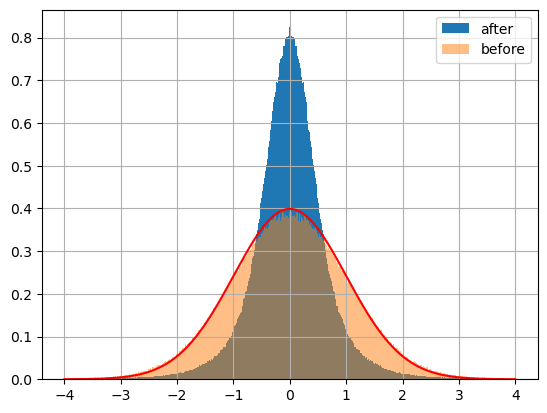

In [6]:
combbb.df2.hist(bins=np.linspace(-4, 4,500), density=True,label='after')
combbb.df1.hist(bins=np.linspace(-4, 4,500), density=True,label='before',alpha=0.5)

x = np.linspace(-4, 4, 33266)
y = norm.pdf(x)
plt.plot(x, y,color='red')
plt.legend()

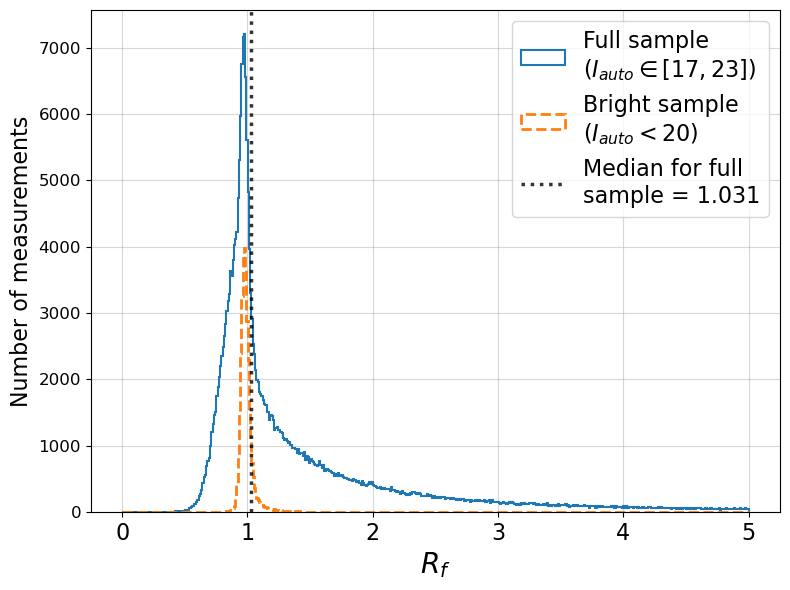

In [9]:
plt.figure(figsize=(8, 6))

flux_ratio_df = pd.DataFrame({
    'flux_ratio': denoisedgalaxyafter['flux_obs_denoised'] / denoisedgalaxyafter['flux_obs']})
filtered = flux_ratio_df[(flux_ratio_df['flux_ratio'] > 0) & (flux_ratio_df['flux_ratio'] < 4)]
median_value = filtered['flux_ratio'].median()

bins_arr = np.linspace(0, 5, 500)

plt.hist(flux_ratio_df['flux_ratio'], bins=bins_arr, histtype='step', 
         label='Full sample\n' + r'$(I_{auto} \in [17,23])$', 
         linestyle='-', linewidth=1.5, color='tab:blue')

plt.hist(flux_ratio_df1['flux_ratio'], bins=bins_arr, histtype='step', 
         label='Bright sample\n' + r'$(I_{auto}<20)$', 
         linestyle='--', linewidth=2.0, color='tab:orange')

plt.xlabel(r'$R_f$', fontsize=20)
plt.ylabel('Number of measurements', fontsize=16)

plt.axvline(median_value, color='black', linestyle=':', linewidth=2.5, 
            alpha=0.8, label=f'Median for full \nsample = {median_value:.3f}')

plt.legend(fontsize=16)
plt.tick_params(axis='x', which='major', labelsize=16)
plt.tick_params(axis='y', which='major', labelsize=12)

plt.grid(True, alpha=0.5) 
plt.tight_layout()
#plt.savefig("/data/aai/scratch/jchan/denoise/PAUS/output_save/loraratio.pdf",format="pdf", bbox_inches="tight")
plt.show()